# RBIG Walk-Through
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/rbig/blob/main/docs/notebooks/03_rbig_walkthrough.ipynb)

This notebook is a self-contained guide to the **Rotation-Based Iterative
Gaussianization (RBIG)** algorithm. It covers the theory, the step-by-step
algorithm, and a hands-on demonstration using the composable `rbig` API.

**Contents**

1. [Why Gaussianization?](#why-gaussianization)
2. [The Density Destructor View](#the-density-destructor-view)
3. [Algorithm Overview](#algorithm-overview)
4. [Data](#data)
5. [Step I — Marginal Gaussianization](#step-i--marginal-gaussianization)
6. [Step II — Rotation (PCA)](#step-ii--rotation-pca)
7. [Single RBIG Layer](#single-rbig-layer-with-rbiglayer)
8. [Full RBIG Model](#full-rbig-model-with-annealedrbig)
9. [Information Theory Measures](#information-theory-measures)
10. [Summary](#summary)

> **Colab / fresh environment?** Run the cell below to install `rbig` from
> GitHub. Skip if already installed.

In [ ]:
!pip install "rbig[all] @ git+https://github.com/jejjohnson/rbig.git" -q

---
## Why Gaussianization?

It is notorious that we say "assume our data is Gaussian". We do this all of
the time in practice because Gaussian data has nice properties:

* **Closed-form solutions** for many statistical quantities
* **Linear dependence structure** — the covariance matrix captures everything
* **Analytical expressions** for entropy, KL-divergence, and mutual information

But as sensors get better, data gets bigger, and algorithms get more
sophisticated, the Gaussian assumption rarely holds in practice.

**What if we could *make* our data Gaussian?** If it were possible, then all of
those nice properties would apply — because the data really *is* Gaussian after
the transformation. This is exactly what Gaussianization does: apply a series
of invertible transformations to map $\mathcal{X}$ to the Gaussian domain
$\mathcal{Z}$.

Gaussianization gives us:

* Process dimensions independently (statistical independence of components)
* Alleviate the curse of dimensionality
* Tackle PDF estimation directly — with a PDF we can sample and assign
  probabilities
* Apply methods that assume Gaussianity
* Get insight into data characteristics via information-theoretic measures

---
## The Density Destructor View

RBIG belongs to the **density destructor** family of methods. A density
destructor is a generative model that transforms a data distribution
$\mathcal{X}$ to a base distribution $\mathcal{Z}$ through an invertible
transformation $\mathcal{G}_\theta$:

$$\begin{aligned}
x &\sim \mathcal{P}_x \quad (\text{Data Distribution})\\
\hat{z} &= \mathcal{G}_\theta(x) \sim \mathcal{P}_z \quad (\text{Base Distribution})
\end{aligned}$$

Because the transforms are invertible, we can use the **change of variables**
formula to get probability estimates of the original data space:

$$p_x(x) = p_z\!\left(\mathcal{G}_\theta(x)\right)
\left|\frac{\partial \mathcal{G}_\theta(x)}{\partial x}\right|
= p_z\!\left(\mathcal{G}_\theta(x)\right)
\left|\nabla_x \mathcal{G}(x)\right|$$

### RBIG vs. Normalizing Flows

If you are familiar with normalizing flows, you'll find similarities. They are
inherently the same family of methods. However, most normalizing flows focus on
minimizing the log-determinant of the Jacobian as a cost function. RBIG has a
different objective: **maximize the negentropy** (or equivalently **minimize
the total correlation**).

**Negentropy** measures departure from Gaussianity:

$$J(\mathbf{x}) = H(\mathbf{x}_\text{gauss}) - H(\mathbf{x})$$

where $H(\mathbf{x}_\text{gauss})$ is the entropy of a Gaussian with the same
covariance as $\mathbf{x}$. By destroying the density (driving negentropy to
zero), we maximize the entropy and remove all redundancies within the
marginals. This formulation also allows us to estimate many information-
theoretic measures (entropy, MI, KLD) as a by-product.

### Historical Context

Gaussianization has been approached via several methods:

* **Projection Pursuit** — iteratively finds directions that maximize
  non-Gaussianity
* **Marginal Gaussianization** — independently transforms each dimension
* **RBIG** — combines marginal Gaussianization with rotations; more
  computationally efficient and simpler to implement than the alternatives

---
## Algorithm Overview

> **Gaussianization** — Given a random variable $\mathbf{x} \in \mathbb{R}^d$,
> a Gaussianization transform is an invertible and differentiable transform
> $\mathcal{G}(\mathbf{x})$ such that
> $\mathcal{G}(\mathbf{x}) \sim \mathcal{N}(0, \mathbf{I})$.

The RBIG iteration is:

$$\mathcal{G}: \mathbf{x}^{(k+1)} = \mathbf{R}_{(k)} \cdot
\mathbf{\Psi}_{(k)}\!\left(\mathbf{x}^{(k)}\right)$$

where:

* $\mathbf{\Psi}_{(k)}$ is the **marginal Gaussianization** of each dimension
  of $\mathbf{x}^{(k)}$ at iteration $k$.
* $\mathbf{R}_{(k)}$ is a **rotation matrix** applied to the marginally
  Gaussianized variable.

Repeating these two steps iteratively drives the joint distribution towards a
standard multivariate Gaussian.

### Marginal Gaussianization ($\Psi$)

To go from any distribution $\mathcal{P}$ to a Gaussian $\mathcal{G}$:

1. Estimate the empirical CDF for each feature
2. Apply the CDF to obtain a uniform variable $u \in [0, 1]$
3. Apply the inverse Gaussian CDF $\Phi^{-1}$ to map to $\mathcal{N}(0,1)$

The pipeline for a single dimension $d$ is:

$$x_d \xrightarrow{F_d} u_d \xrightarrow{\Phi^{-1}} z_d$$

### Rotation ($R$)

The rotation must be orthogonal, orthonormal, and invertible. Options include:

* **PCA** — Principal Components Analysis (default)
* **ICA** — Independent Components Analysis
* **Random** — Random orthogonal rotations

The full transformation at each layer:

$$\mathcal{P} \rightarrow \mathcal{U} \rightarrow \mathcal{G}
\rightarrow \mathbf{R} \cdot \mathcal{G}$$

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

from rbig import AnnealedRBIG, MarginalGaussianize, PCARotation, RBIGLayer

plt.style.use("seaborn-v0_8-paper")

/anaconda/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def plot_2d_joint(data, title="Data", color="steelblue"):
    _fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(data[:, 0], data[:, 1], s=5, alpha=0.5, color=color)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    plt.show()

---
## Data

We generate a 2-D "sin-wave" dataset — a non-Gaussian joint distribution with
visible nonlinear dependence.

Data shape: (2000, 2)


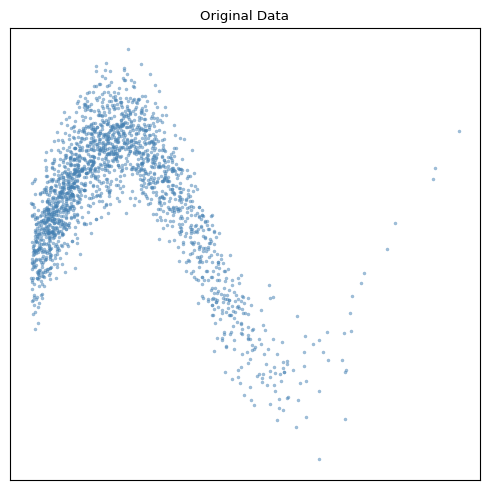

In [3]:
seed = 123
rng = np.random.RandomState(seed=seed)

num_samples = 2_000
x = np.abs(2 * rng.randn(1, num_samples))
y = np.sin(x) + 0.25 * rng.randn(1, num_samples)
data = np.vstack((x, y)).T

print(f"Data shape: {data.shape}")
plot_2d_joint(data, title="Original Data")

---
## Step I — Marginal Gaussianization

We use `MarginalGaussianize` to transform each feature independently to
approximately standard Gaussian using the empirical CDF + probit.

This is the $\mathbf{\Psi}$ step: for each dimension $d$, we estimate the
empirical CDF $F_d$, apply it to get a uniform variable, and then apply
$\Phi^{-1}$ to obtain a Gaussian variable.

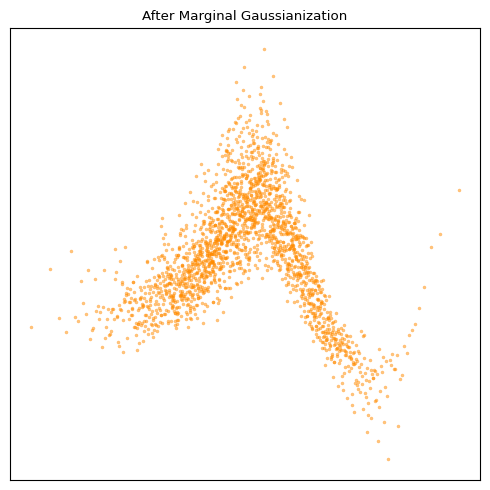

In [4]:
mg = MarginalGaussianize()
mg.fit(data)
data_mg = mg.transform(data)

plot_2d_joint(data_mg, title="After Marginal Gaussianization", color="darkorange")

After this step each marginal is approximately Gaussian, but the joint
distribution still shows dependence (the scatter plot is not circular).

---
## Step II — Rotation (PCA)

We apply `PCARotation` with whitening to decorrelate the Gaussianized features.
This is the $\mathbf{R}$ step: it mixes the dimensions so that the next round
of marginal Gaussianization can attack the remaining dependence structure.

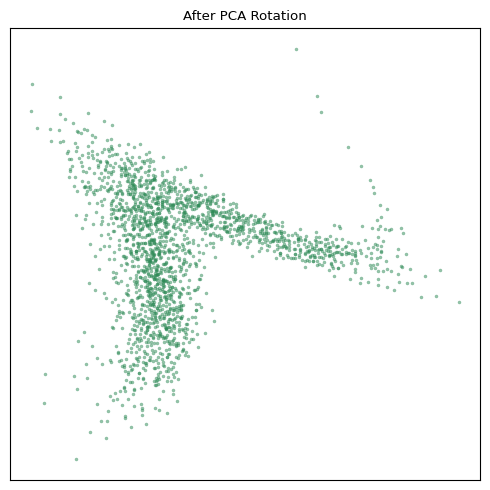

In [5]:
pca_rot = PCARotation(whiten=True)
pca_rot.fit(data_mg)
data_rot = pca_rot.transform(data_mg)

plot_2d_joint(data_rot, title="After PCA Rotation", color="seagreen")

One RBIG layer (marginal Gaussianization + rotation) has already significantly
reduced the dependence.  However, for strongly non-Gaussian data we need many
layers.

---
## Single RBIG Layer with `RBIGLayer`

The two steps above are packaged into a single `RBIGLayer`.

In [6]:
layer = RBIGLayer(
    marginal=MarginalGaussianize(),
    rotation=PCARotation(whiten=True),
)
layer.fit(data)
data_layer = layer.transform(data)

# Verify that RBIGLayer produces a transform with similar statistics
mean_manual = np.mean(data_rot, axis=0)
mean_layer = np.mean(data_layer, axis=0)
cov_manual = np.cov(data_rot, rowvar=False)
cov_layer = np.cov(data_layer, rowvar=False)

np.testing.assert_allclose(mean_layer, mean_manual, rtol=1e-3, atol=1e-3)
np.testing.assert_allclose(cov_layer, cov_manual, rtol=1e-3, atol=1e-3)
print(
    "RBIGLayer output has similar mean and covariance to manual marginal + rotation steps ✓"
)

RBIGLayer output has similar mean and covariance to manual marginal + rotation steps ✓


### Inverse transform

`RBIGLayer` is an invertible transform: we can map the Gaussianized data back
to the original space.

In [7]:
data_reconstructed = layer.inverse_transform(data_layer)
residual = np.abs(data - data_reconstructed).mean()
print(f"Mean absolute reconstruction error: {residual:.4e}")

Mean absolute reconstruction error: 1.0400e-03


---
## Layer Progression

To visualize how the distribution evolves, we show the output after 1, 3, and
5 RBIG layers. With each additional layer the joint distribution becomes more
circular (more Gaussian).

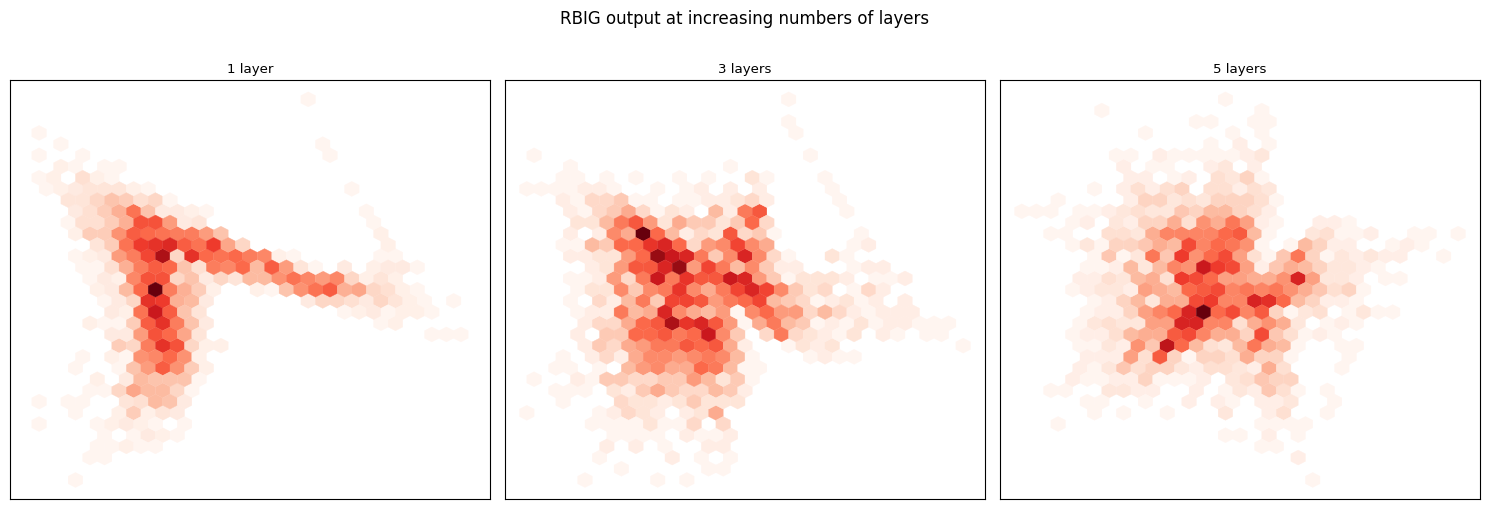

In [8]:
import seaborn as sns

n_layer_list = [1, 3, 5]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, n in zip(axes, n_layer_list, strict=False):
    model_n = AnnealedRBIG(
        n_layers=n,
        rotation="pca",
        patience=n + 1,  # never stop early in this demo
        random_state=seed,
    )
    Z_n = model_n.fit_transform(data)
    ax.hexbin(Z_n[:, 0], Z_n[:, 1], gridsize=30, cmap="Reds", mincnt=1)
    ax.set_title(f"{n} layer{'s' if n > 1 else ''}")
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle("RBIG output at increasing numbers of layers", y=1.01)
plt.tight_layout()
plt.show()

---
## Full RBIG Model with `AnnealedRBIG`

`AnnealedRBIG` stacks many `RBIGLayer` instances and iterates until the total
correlation (TC) converges. Recall that RBIG's objective is to minimize TC —
when TC reaches zero, the data is factorial Gaussian and no more layers are
needed.

In [9]:
rbig_model = AnnealedRBIG(
    n_layers=50,
    rotation="pca",
    patience=10,
    random_state=seed,
)
rbig_model.fit(data)

print(f"Number of layers fitted: {len(rbig_model.layers_)}")

Number of layers fitted: 27


### Transformed data

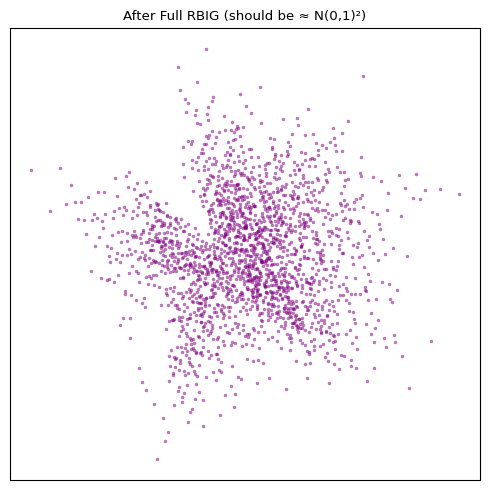

In [10]:
data_gauss = rbig_model.transform(data)
plot_2d_joint(data_gauss, title="After Full RBIG (should be ≈ N(0,1)²)", color="purple")

### Total correlation per layer

`tc_per_layer_` records the total correlation of the data **after** each layer.
It should decrease monotonically towards zero as the algorithm drives the data
towards a factorial Gaussian.

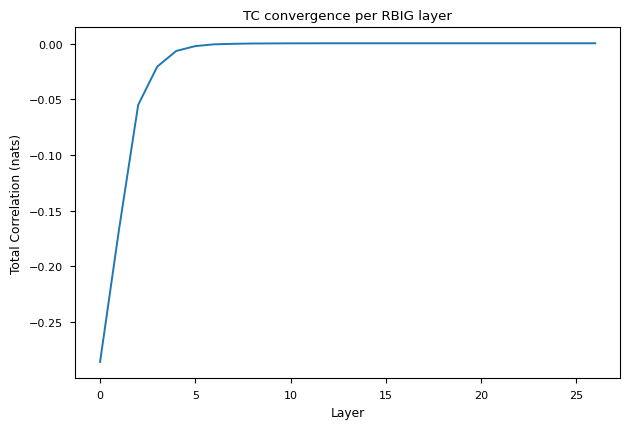

In [11]:
fig, ax = plt.subplots()
ax.plot(rbig_model.tc_per_layer_)
ax.set_xlabel("Layer")
ax.set_ylabel("Total Correlation (nats)")
ax.set_title("TC convergence per RBIG layer")
plt.tight_layout()
plt.show()

### Inverse transform (reconstruction)

In [12]:
data_inv = rbig_model.inverse_transform(data_gauss)
residual_full = np.abs(data - data_inv).mean()
print(f"Full RBIG mean absolute reconstruction error: {residual_full:.4e}")

Full RBIG mean absolute reconstruction error: 2.5275e-02


---
## Information Theory Measures

A key advantage of the density destructor formulation is that we can estimate
classical information-theoretic quantities directly from the RBIG
transformation. Because RBIG iteratively removes structure (reduces TC), the
entropy reduction at each layer gives us a natural estimator.

![Information Theory measures overview](../notes/pics/rbig_it/Fig_1.png)

### Entropy

The entropy of the data decreases at each RBIG iteration as the distribution
approaches a multivariate Gaussian. The total entropy can be estimated by
summing the entropy reductions across all layers.

### Mutual Information

![Mutual Information using RBIG](../notes/pics/rbig_it/mi.png)

Given two random vectors $\mathbf{X}$ and $\mathbf{Y}$, we first Gaussianize
each independently, then measure the total correlation of the joint:

$$I(\mathbf{X}, \mathbf{Y}) = T\!\left(\left[
    \mathcal{G}_\theta(\mathbf{X}),\;
    \mathcal{G}_\phi(\mathbf{Y})
\right]\right)$$

See [notebook 06](./06_information_theory.ipynb) for the functional API
(`mutual_information_rbig`) and [notebooks 09–10](./09_dependence_1d.ipynb)
for practical dependence-detection examples.

### KL-Divergence

![KL-Divergence using RBIG](../notes/pics/rbig_it/kld.png)

Let $\mathcal{G}_\theta(\mathbf{X})$ be the Gaussianization of $\mathbf{X}$.
We can estimate the KL-divergence between two distributions by applying the
Gaussianization learned on $\mathbf{Y}$ to samples from $\mathbf{X}$:

$$D_\text{KL}\!\left[\mathbf{X} \| \mathbf{Y}\right]
= D_\text{KL}\!\left[\mathbf{X} \| \mathcal{G}_\theta(\mathbf{Y})\right]
= J\!\left[\mathcal{G}_\theta(\hat{\mathbf{y}})\right]$$

See [notebook 06](./06_information_theory.ipynb) for the functional API
(`kl_divergence_rbig`).

---
## Summary

| Concept | Description |
|---|---|
| **Gaussianization** | Invertible transform mapping data to $\mathcal{N}(0, \mathbf{I})$ |
| **Density Destructor** | Destroys structure iteratively; enables exact likelihood via change of variables |
| **Objective** | Minimize total correlation (equivalently, maximize negentropy) |
| **RBIG iteration** | $\mathbf{x}^{(k+1)} = \mathbf{R}_{(k)} \cdot \mathbf{\Psi}_{(k)}(\mathbf{x}^{(k)})$ |
| **IT measures** | Entropy, MI, KLD estimated as by-products of the Gaussianization |

| API Class | Role |
|---|---|
| `MarginalGaussianize` | Marginal Gaussianization via empirical CDF + probit |
| `PCARotation` | Whitening PCA rotation |
| `RBIGLayer` | One RBIG layer = marginal + rotation |
| `AnnealedRBIG` | Full iterative model with convergence detection |

### References

* Iterative Gaussianization: from ICA to Random Rotations — Laparra et al.
  (2011) — IEEE Transactions on Neural Networks —
  [Paper](https://arxiv.org/abs/1602.00229)
* Gaussianization — Chen & Gopinath (2000) —
  [PDF](https://papers.nips.cc/paper/1856-gaussianization.pdf)